# Home Credit Default Risk Analysis — Data Preparation

## 1. Project overview

У цьому проєкті аналізується датасет Home Credit Default Risk, який містить інформацію про клієнтів, їхні заявки на кредит, фінансові характеристики та історію попередніх заявок.

Основна ціль проєкту — дослідити фактори, пов’язані з ризиком дефолту, а також проаналізувати попередні заявки клієнтів для формування практичних бізнес-висновків щодо risk segmentation та offer strategy.

Фокус аналізу:
- default risk;
- клієнтські сегменти;
- співвідношення кредиту до доходу;
- previous application funnel;
- offer gap;
- статистична перевірка гіпотези;
- базове ML-прогнозування як додатковий блок.

У цьому проєкті для аналізу використовую дві основні таблиці з датасету Home Credit Default Risk:

- `application_train.csv` — основна таблиця з інформацією про поточні кредитні заявки клієнтів, фінансові показники, соціально-демографічні ознаки та цільову змінну `TARGET`;
- `previous_application.csv` — таблиця з історією попередніх заявок клієнтів, яка містить статуси попередніх заявок, типи кредитних продуктів, суми заявки та погодженого кредиту.

Основний аналіз будується навколо таблиці `application_train`, а таблиця `previous_application` використовується для додаткового аналізу кредитної історії клієнтів, статусів попередніх заявок та `offer gap`.

## 2. Data loading and environment setup

Для роботи з даними використовую Python-бібліотеки `pandas`, `numpy`, `matplotlib`, `seaborn` та `duckdb`.

`pandas` використовується для завантаження, очищення та аналізу даних.  
`duckdb` дозволяє виконувати SQL-запити напряму в Python без окремого підключення до бази даних.

У цьому проєкті дані зберігаються локально у CSV-файлах, тому немає потреби створювати окрему базу або підключатися через DBeaver.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display_html
from pathlib import Path

Завантажую дві основні таблиці, які будуть використані в подальшому аналізі.

In [2]:
# Завантаження даних 

app = pd.read_csv("../data/raw/application_train.csv")
prev = pd.read_csv("../data/raw/previous_application.csv")

## 3. Data overview

### 3.1. Application train overview

In [3]:
# Перевірка розміру

print(f"Application_train: {app.shape[0]} rows, {app.shape[1]} columns")

Application_train: 307511 rows, 122 columns


In [4]:
# Перегляд перших рядків

app.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Опис наявних даних

app_dtypes = app.dtypes.value_counts().reset_index()
app_dtypes.columns = ["data_type", "columns_count"]

display(app_dtypes)

,data_type,columns_count
0,float64,65
1,int64,41
2,str,16


In [6]:
print(f"Duplicates in application_train: {app.duplicated().sum()}")

Duplicates in application_train: 0


### 3.2. Previous application overview

In [7]:
print(f"Previous_application: {prev.shape[0]} rows, {prev.shape[1]} columns")

Previous_application: 1670214 rows, 37 columns


In [8]:
prev.head(3)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0


In [9]:
prev_dtypes = prev.dtypes.value_counts().reset_index()
prev_dtypes.columns = ["data_type", "columns_count"]

display(prev_dtypes)

,data_type,columns_count
0,str,16
1,float64,15
2,int64,6


In [10]:
print(f"Duplicates in previous_application: {prev.duplicated().sum()}")

Duplicates in previous_application: 0


### 3.3. Key columns and target variable
На цьому етапі перевіряю розподіл цільової змінної `TARGET`, яка показує факт дефолту клієнта.

In [11]:
target_distribution = (
    app["TARGET"]
    .value_counts()
    .reset_index()
)

target_distribution.columns = ["TARGET", "clients_count"]

target_distribution["clients_percent"] = (
    target_distribution["clients_count"] / target_distribution["clients_count"].sum() * 100
).round(2)

target_distribution["target_label"] = target_distribution["TARGET"].map({
    0: "No default",
    1: "Default"
})

target_distribution = target_distribution[
    ["TARGET", "target_label", "clients_count", "clients_percent"]
]

target_distribution

,TARGET,target_label,clients_count,clients_percent
0,0,No default,282686,91.93
1,1,Default,24825,8.07


**Висновок:**  

Цільова змінна `TARGET` показує, чи мав клієнт проблеми з погашенням кредиту.

- `TARGET = 0` — клієнт не допустив дефолт.
- `TARGET = 1` — клієнт допустив дефолт.

Початковий розподіл показує, що дефолтна група значно менша за недефолтну, тому це потрібно враховувати в подальшому аналізі.

### 3.4 Missing values overview

На цьому етапі перевіряю частку пропущених значень у таблицях `application_train` та `previous_application`.

Це потрібно, щоб зрозуміти, які колонки мають багато пропусків і потребують окремого рішення на етапі очищення даних.

In [12]:
missing_app = (
    app.isna().mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

missing_app.columns = ["column", "missing_percent"]
missing_app.head(20)

,column,missing_percent
0,COMMONAREA_AVG,69.87
1,COMMONAREA_MODE,69.87
2,COMMONAREA_MEDI,69.87
3,NONLIVINGAPARTMENTS_MEDI,69.43
4,NONLIVINGAPARTMENTS_MODE,69.43
5,NONLIVINGAPARTMENTS_AVG,69.43
6,FONDKAPREMONT_MODE,68.39
7,LIVINGAPARTMENTS_AVG,68.35
8,LIVINGAPARTMENTS_MEDI,68.35
9,LIVINGAPARTMENTS_MODE,68.35


In [13]:
missing_prev = (
    prev.isna().mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

missing_prev.columns = ["column", "missing_percent"]
missing_prev.head(20)

,column,missing_percent
0,RATE_INTEREST_PRIVILEGED,99.64
1,RATE_INTEREST_PRIMARY,99.64
2,AMT_DOWN_PAYMENT,53.64
3,RATE_DOWN_PAYMENT,53.64
4,NAME_TYPE_SUITE,49.12
5,DAYS_TERMINATION,40.30
6,DAYS_FIRST_DRAWING,40.30
7,DAYS_FIRST_DUE,40.30
8,DAYS_LAST_DUE_1ST_VERSION,40.30
9,DAYS_LAST_DUE,40.30


**Висновок:**  
В обох таблицях є колонки з великою часткою пропущених значень.

В `application_train` найбільше пропусків мають ознаки, пов’язані з характеристиками житла клієнта.  
В `previous_application` найбільше пропусків мають процентні ставки, сума першого внеску та частина колонок, пов’язаних з датами попередніх заявок.

На цьому етапі колонки не видаляю, а лише фіксую проблему. Рішення щодо обробки пропусків буде прийняте на етапі `Data cleaning`.

### 3.5. Initial observations

- `application_train` є основною таблицею для аналізу дефолту, оскільки містить цільову змінну `TARGET`.
- `previous_application` містить історію попередніх заявок клієнтів і буде використана для аналізу статусів заявок, воронки та offer gap.
- У таблицях немає повних дублікатів.
- Цільова змінна `TARGET` є незбалансованою: частка дефолтних клієнтів становить близько 8%.
- Обидві таблиці мають пропущені значення, тому перед глибшим аналізом потрібно визначити підхід до їх обробки.

### 3.6 Data dictionary review

На цьому етапі переглядаю опис колонок, щоб визначити ключові поля для подальшого аналізу дефолту, клієнтських сегментів, попередніх заявок та offer gap.

In [14]:
columns_desc = pd.read_excel("../data/processed/HomeCredit_columns_description_UA.xlsx")

columns_desc.head(3)

,№,Table,Row,Опис,Special
0,1,application_{train|test},SK_ID_CURR,ID кредиту в нашій вибірці,228
1,2,application_{train|test},TARGET,Цільова змінна (1 — клієнт із труднощами з опл...,228
2,3,application_{train|test},NAME_CONTRACT_TYPE,"Ознака, чи кредит є готівковим або револьверни...",228


In [15]:
key_columns = [
    "SK_ID_CURR",
    "TARGET",
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "SK_ID_PREV",
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "NAME_CONTRACT_STATUS",
    "NAME_CLIENT_TYPE",
    "NAME_PRODUCT_TYPE",
    "CHANNEL_TYPE"
]

In [16]:
key_columns_desc = columns_desc[columns_desc["Row"].isin(key_columns)]

key_columns_desc.style.hide(axis="index")

№,Table,Row,Опис,Special
1,application_{train|test},SK_ID_CURR,ID кредиту в нашій вибірці,228
2,application_{train|test},TARGET,Цільова змінна (1 — клієнт із труднощами з оплатою: мав/мала прострочення більше ніж X днів хоча б за одним із перших Y платежів кредиту в нашій вибірці; 0 — всі інші випадки),228
3,application_{train|test},NAME_CONTRACT_TYPE,"Ознака, чи кредит є готівковим або револьверний кредит (кредитна лінія)",228
4,application_{train|test},CODE_GENDER,Стать клієнта,228
7,application_{train|test},CNT_CHILDREN,Кількість дітей у клієнта,228
8,application_{train|test},AMT_INCOME_TOTAL,Дохід клієнта,228
9,application_{train|test},AMT_CREDIT,Сума кредиту,228
10,application_{train|test},AMT_ANNUITY,Ануїтетний платіж за кредитом,228
13,application_{train|test},NAME_INCOME_TYPE,"Тип доходу клієнта (підприємець, найманий працівник, декретна відпустка тощо)",228
14,application_{train|test},NAME_EDUCATION_TYPE,Рівень освіти клієнта,228


**Висновок:**  
На основі data dictionary відібрано ключові колонки для подальшого аналізу: цільова змінна `TARGET`, фінансові показники клієнта, соціально-демографічні ознаки, зовнішні скорингові ознаки та поля з попередніх заявок для аналізу статусів і offer gap.

## 4. Data cleaning

Мета етапу — перевірити якість даних перед подальшим аналізом та підготувати основні поля для EDA і feature engineering.

У цьому блоці перевіряю:

- аномальні значення у ключових числових полях;
- можливі викиди у фінансових показниках;
- спеціальні значення у колонках `DAYS_BIRTH` та `DAYS_EMPLOYED`;
- підхід до обробки пропущених значень.

На цьому етапі не очищаю всі 122 колонки, а фокусуюсь на полях, які будуть використані в основному аналізі.

In [17]:
# Створення робочих копій

app_clean = app.copy()
prev_clean = prev.copy()

In [18]:
# Ключові числові стовпці для початкової перевірки на наявність винятків

app_numeric_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

app_clean[app_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0


Фінансові поля мають широкий діапазон значень, що очікувано для кредитних даних: клієнти відрізняються за доходом, сумою кредиту та ануїтетним платежем.

Колонки `DAYS_BIRTH` та `DAYS_EMPLOYED` зберігаються не як звичайні дати, а як кількість днів відносно дати заявки. Тому їх потрібно буде перетворити у зрозумілі показники: `age_years` та `employment_years`.

У полі `DAYS_EMPLOYED` видно аномальне максимальне значення `365243`, яке потребує окремої обробки.

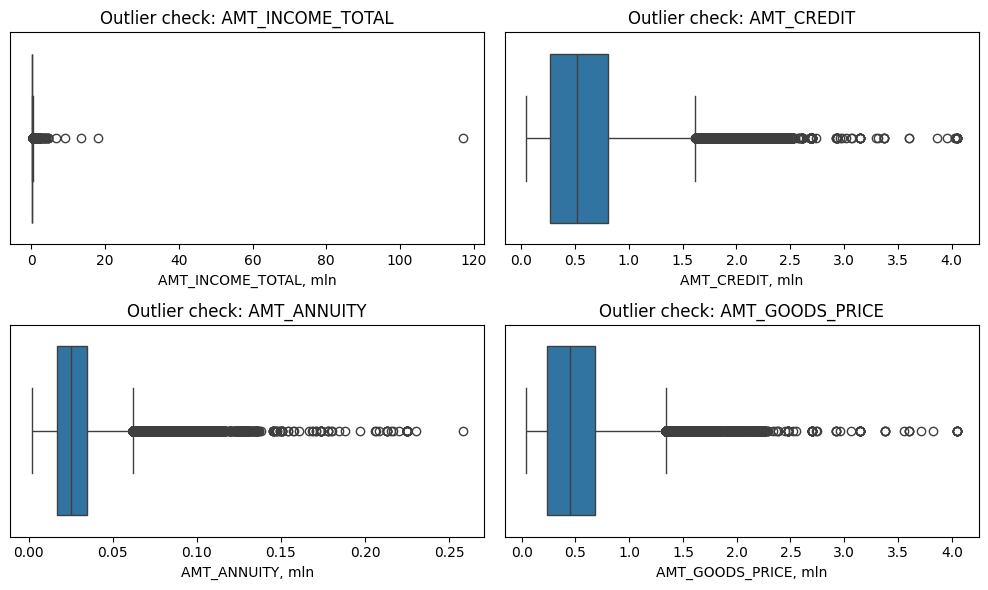

In [19]:
# Boxplots для основних фінансових стовпців

financial_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(financial_cols):
    sns.boxplot(x=app_clean[col] / 1_000_000, ax=axes[i])
    axes[i].set_title(f"Outlier check: {col}")
    axes[i].set_xlabel(f"{col}, mln")
    axes[i].set_yticks([])

plt.tight_layout()
plt.show()

Boxplot-графіки показують наявність викидів у всіх ключових фінансових полях. Найбільш помітні викиди є в `AMT_INCOME_TOTAL`, де окремі клієнти мають значно вищий дохід порівняно з основною масою спостережень.

На цьому етапі викиди не видаляю, оскільки для кредитних даних такі значення можуть бути реальними бізнес-випадками.

In [20]:
# Таблиця по викидах через IQR

outlier_summary = []

for col in financial_cols:
    q1 = app_clean[col].quantile(0.25)
    q3 = app_clean[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers_count = app_clean[
        (app_clean[col] < lower_bound) | (app_clean[col] > upper_bound)
    ].shape[0]
    
    outlier_summary.append({
        "column": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outliers_count": outliers_count,
        "outliers_percent": round(outliers_count / len(app_clean) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,column,lower_bound,upper_bound,outliers_count,outliers_percent
0,AMT_INCOME_TOTAL,-22500.0,337500.0,14035,4.56
1,AMT_CREDIT,-537975.0,1616625.0,6562,2.13
2,AMT_ANNUITY,-10584.0,61704.0,7504,2.44
3,AMT_GOODS_PRICE,-423000.0,1341000.0,14728,4.79


За правилом IQR частка потенційних викидів у фінансових полях становить приблизно від 2% до 5%.

Найбільша частка викидів спостерігається у `AMT_GOODS_PRICE` та `AMT_INCOME_TOTAL`. Це підтверджує, що фінансові показники мають нерівномірний розподіл, але автоматично видаляти ці значення не варто.

In [21]:
# Перевірка спеціального значення в полі DAYS_EMPLOYED

special_employed_value = 365243

special_employed_count = (app["DAYS_EMPLOYED"] == special_employed_value).sum()
special_employed_percent = round(
    special_employed_count / len(app) * 100, 2
)

print(f"Rows with DAYS_EMPLOYED = 365243: {special_employed_count}")
print(f"Percent of dataset: {special_employed_percent}%")

Rows with DAYS_EMPLOYED = 365243: 55374
Percent of dataset: 18.01%


In [22]:
# Аномальне значення замінємо на NaN і перевіряємо максимальне

app_clean["DAYS_EMPLOYED"] = app_clean["DAYS_EMPLOYED"].replace(365243, np.nan)

print(f"Max DAYS_EMPLOYED after replacement: {app_clean['DAYS_EMPLOYED'].max()}")

Max DAYS_EMPLOYED after replacement: 0.0


У сирих даних колонка `DAYS_EMPLOYED` містить спеціальне значення `365243` у 55 374 рядках, що становить 18.01% вибірки. Це значення не відображає реальний стаж роботи, тому для подальшого аналізу воно замінене на `NaN` у робочій копії `app_clean`.

### Categorical columns check

На цьому етапі перевіряю основні категоріальні поля, які будуть використані для сегментації клієнтів у EDA.

Ці колонки не потребують складної обробки зараз, але важливо перевірити, які категорії в них є.

In [23]:
categorical_cols = [
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS"
]

tables_html = []

for col in categorical_cols:
    category_summary = (
        app_clean[col]
        .value_counts(dropna=False)
        .reset_index()
    )
    
    category_summary.columns = ["category", "clients_count"]
    
    category_summary["clients_percent"] = (
        category_summary["clients_count"] / category_summary["clients_count"].sum() * 100
    ).round(2)
    
    table_html = f"""
    <div style="display:inline-block; vertical-align:top; width:32%; margin-right:1%;">
        <h4>{col}</h4>
        {category_summary.to_html(index=False)}
    </div>
    """
    
    tables_html.append(table_html)

display_html("".join(tables_html), raw=True)

category,clients_count,clients_percent
Working,158774,51.63
Commercial associate,71617,23.29
Pensioner,55362,18.00
State servant,21703,7.06
Unemployed,22,0.01
Student,18,0.01
Businessman,10,0.00
Maternity leave,5,0.00
category,clients_count,clients_percent
Secondary / secondary special,218391,71.02


Основні категоріальні поля містять зрозумілі групи клієнтів за типом доходу, рівнем освіти та сімейним статусом.

У `NAME_FAMILY_STATUS` є категорія `Unknown`, але вона містить лише 2 записи, тому на цьому етапі не потребує окремої обробки.

Ці поля будуть використані далі в EDA для аналізу default rate у різних клієнтських сегментах.

**Висновок:**  
У ключових фінансових полях є викиди, що очікувано для кредитних даних: клієнти можуть мати дуже різний дохід, суму кредиту та ануїтетний платіж.

Колонка `DAYS_EMPLOYED` містить спеціальне аномальне значення `365243`, яке не відображає реальний стаж роботи. Для подальшого аналізу це значення замінено на `NaN`.

На цьому етапі викиди не видаляю автоматично, оскільки вони можуть бути реальними бізнес-випадками. Остаточні рішення щодо обробки прийматимуться під час EDA та feature engineering.

## 5. Feature engineering

Мета етапу — створити нові аналітичні ознаки, які допоможуть краще оцінити ризик дефолту клієнтів.

У цьому блоці створюю:

- `age_years` — вік клієнта у роках;
- `employment_years` — стаж роботи у роках;
- `credit_income_ratio` — співвідношення суми кредиту до доходу;
- `annuity_income_ratio` — співвідношення ануїтетного платежу до доходу.

In [24]:
# Створення нових ознак для подальшого аналізу

app_clean["age_years"] = (-app_clean["DAYS_BIRTH"] / 365).round(1)

app_clean["employment_years"] = (-app_clean["DAYS_EMPLOYED"] / 365).round(1)

app_clean["credit_income_ratio"] = (app_clean["AMT_CREDIT"] / app_clean["AMT_INCOME_TOTAL"]).round(2)

app_clean["annuity_income_ratio"] = (app_clean["AMT_ANNUITY"] / app_clean["AMT_INCOME_TOTAL"]).round(2)

In [25]:
new_features = [
    "age_years",
    "employment_years",
    "credit_income_ratio",
    "annuity_income_ratio"
]

feature_stats = app_clean[new_features].describe().T

feature_stats[["mean", "std"]] = feature_stats[["mean", "std"]].round(2)

feature_stats

,count,mean,std,min,25%,50%,75%,max
age_years,307511.0,43.94,11.96,20.5,34.00,43.20,53.90,69.10
employment_years,252137.0,6.53,6.41,0.0,2.10,4.50,8.70,49.10
credit_income_ratio,307511.0,3.96,2.69,0.0,2.02,3.27,5.16,84.74
annuity_income_ratio,307499.0,0.18,0.09,0.0,0.11,0.16,0.23,1.88


У статистиці нових ознак видно, що `credit_income_ratio` має дуже високе максимальне значення — `84.74`. Додатково перевіряю найбільші значення цієї ознаки.

In [26]:
# Перевірка найбільших значень credit_income_ratio (мах - 84,74)

app_clean[
    [
        "SK_ID_CURR",
        "TARGET",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "credit_income_ratio",
        "annuity_income_ratio"
    ]
].sort_values("credit_income_ratio", ascending=False).head(10)

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,credit_income_ratio,annuity_income_ratio
20727,124157,1,25650.0,2173500.0,84.74,1.88
35791,141454,0,45000.0,2215224.0,49.23,1.30
226137,361920,1,45000.0,1800000.0,40.00,1.39
255247,395348,1,58500.0,2146500.0,36.69,0.88
158077,283247,0,40500.0,1436850.0,35.48,1.04
678,100784,1,54000.0,1885500.0,34.92,1.37
205575,338291,1,36000.0,1223010.0,33.97,1.35
103862,220543,0,54000.0,1800000.0,33.33,0.88
165555,291918,0,27000.0,900000.0,33.33,0.97
193574,324475,0,27900.0,916470.0,32.85,0.97


In [27]:
high_credit_income = app_clean[app_clean["credit_income_ratio"] > 10]

print(f"Rows with credit_income_ratio > 10: {len(high_credit_income)}")
print(f"Percent of dataset: {round(len(high_credit_income) / len(app_clean) * 100, 2)}%")

Rows with credit_income_ratio > 10: 9838
Percent of dataset: 3.2%


Клієнти з `credit_income_ratio > 10` становлять близько `3.2%` вибірки. На цьому етапі ці значення не видаляю, але врахую їх під час подальшого аналізу та візуалізацій.

In [28]:
# Створення сегментів для подальшого аналізу default rate

app_clean["age_group"] = pd.cut(
    app_clean["age_years"],
    bins=[20, 30, 40, 50, 60, 70],
    labels=["20-29", "30-39", "40-49", "50-59", "60-69"],
    right=False
)

app_clean["children_group"] = np.where(
    app_clean["CNT_CHILDREN"] > 0,
    "Has children",
    "No children"
)

In [29]:
app_clean[["age_years", "age_group", "CNT_CHILDREN", "children_group"]].head()

,age_years,age_group,CNT_CHILDREN,children_group
0,25.9,20-29,0,No children
1,45.9,40-49,0,No children
2,52.2,50-59,0,No children
3,52.1,50-59,0,No children
4,54.6,50-59,0,No children


Додатково створено сегменти `age_group` та `children_group`, які будуть використані в EDA для аналізу default rate за віком та наявністю дітей.

**Висновок:**  
На цьому етапі створено нові аналітичні ознаки для подальшого EDA: вік клієнта, стаж роботи, співвідношення кредиту до доходу, ануїтетного платежу до доходу, вікову групу та групу за наявністю дітей.

Створені ознаки будуть використані для оцінки фінансового навантаження клієнтів і аналізу default rate у різних сегментах.

In [30]:
# Зберігаємо підготовлені файли для подальшого аналізу

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

app_clean.to_csv(processed_path / "app_clean.csv", index=False, encoding="utf-8-sig")
prev_clean.to_csv(processed_path / "prev_clean.csv", index=False, encoding="utf-8-sig")

print("Processed files saved successfully.")

Processed files saved successfully.


Підготовлені файли `app_clean.csv` та `prev_clean.csv` збережено в папку `data/processed`.

Вони будуть використані в наступних ноутбуках для EDA, SQL-аналізу, перевірки гіпотези, ML-блоку та підготовки даних для Tableau.